In [1]:
# ================================
# 1. IMPORT LIBRARIES
# ================================
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ================================
# 2. LOAD DATA
# ================================
df = pd.read_csv("heart_disease_uci.csv")

print("Dataset Shape:", df.shape)

Dataset Shape: (920, 16)


In [3]:
# ================================
# 3. DATA PREPROCESSING
# ================================
df = df.dropna()

# Identify target column
target_column = 'target' if 'target' in df.columns else 'num'

X = df.drop(columns=[target_column])
y = df[target_column]

# Convert categorical columns → numeric
X = pd.get_dummies(X, drop_first=True)

# Save column structure
training_columns = X.columns.tolist()

# Convert target to binary
y = y.apply(lambda x: 1 if x > 0 else 0)

In [4]:
# ================================
# 4. TRAIN / VALIDATION / TEST SPLIT
# ================================
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)
# Final: 60% train / 20% val / 20% test

In [5]:

# ================================
# 5. FEATURE SCALING
# ================================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [6]:
# ================================
# 6. TRAIN MODEL
# ================================
model = LogisticRegression(max_iter=1000, solver='lbfgs')
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [7]:
# ================================
# 7. ACCURACY (TRAIN / VAL / TEST)
# ================================
train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
val_acc = accuracy_score(y_val, model.predict(X_val_scaled))
test_pred = model.predict(X_test_scaled)
test_acc = accuracy_score(y_test, test_pred)

precision = precision_score(y_test, test_pred)
recall = recall_score(y_test, test_pred)
f1 = f1_score(y_test, test_pred)

print("\n===== LOGISTIC REGRESSION RESULTS =====")
print(f"Training Accuracy   : {train_acc:.4f}")
print(f"Validation Accuracy : {val_acc:.4f}")
print(f"Test Accuracy       : {test_acc:.4f}")
print(f"Precision           : {precision:.4f}")
print(f"Recall              : {recall:.4f}")
print(f"F1 Score            : {f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, test_pred))



===== LOGISTIC REGRESSION RESULTS =====
Training Accuracy   : 0.8939
Validation Accuracy : 0.8500
Test Accuracy       : 0.8333
Precision           : 0.8462
Recall              : 0.7857
F1 Score            : 0.8148

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.88      0.85        32
           1       0.85      0.79      0.81        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60



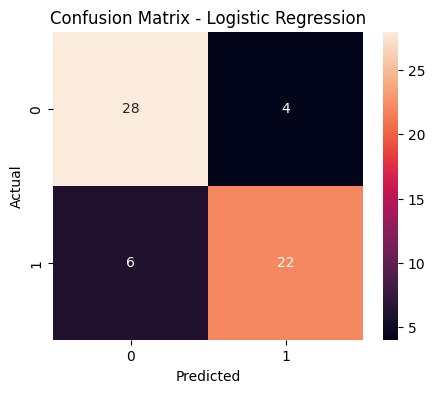

In [8]:
# ================================
# 8. CONFUSION MATRIX
# ================================
cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [9]:
# ================================
# 9. SAVE MODEL FILES
# ================================
joblib.dump(model, "logistic_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(training_columns, "columns.pkl")

print("\nModel saved successfully.")


Model saved successfully.


In [10]:
# ================================
# 10. MANUAL INPUT TESTING
# ================================

# Example input (CHANGE VALUES BASED ON YOUR DATASET)
manual_input = {
    'age': 55,
    'sex': 'Male',
    'cp': 'asymptomatic',
    'trestbps': 140,
    'chol': 240,
    'fbs': True,
    'restecg': 'normal',
    'thalch': 150,
    'exang': False,
    'oldpeak': 1.5,
    'slope': 'flat',
    'ca': 0.0,
    'thal': 'fixed_defect'
}

input_df = pd.DataFrame([manual_input])

# Apply same encoding
input_df = pd.get_dummies(input_df, drop_first=True)

# Add missing columns
for col in training_columns:
    if col not in input_df.columns:
        input_df[col] = 0

# Match column order
input_df = input_df[training_columns]

# Scale input
input_scaled = scaler.transform(input_df)

# Predict
prediction = model.predict(input_scaled)[0]
probability = model.predict_proba(input_scaled)[0][1]

print("\n===== MANUAL TEST RESULT =====")
print("Prediction:", "Heart Disease" if prediction == 1 else "No Heart Disease")
print(f"Probability: {probability:.4f}")


===== MANUAL TEST RESULT =====
Prediction: No Heart Disease
Probability: 0.2653
